# Mini Project 2: Where Will Dicty Meet?




## **1. Approach Description**

The goal of this project is to **predict the final aggregation center of Dictyostelium discoideum** colonies.
Each video consists of a time-lapse sequence in which Dicty cells gradually move and converge toward a final aggregation spot. The final hotspot (center) is not annotated per-frame; only the final location is detectable from late bright frames.

Thus, the challenge is:

> **Given the first K frames (K ≪ T), predict the final aggregation center (row,col).
> How early can we make an accurate prediction?**

Our approach includes:

1. **Data loading** (handling AVI files).
2. **A preprocessing pipeline** to normalize and denoise frames.
3. **One baselines** (Center-of-Mass).
4. **Two CNN-based regression model** (2D and optionally 3D variants).
5. **A fair temporal split** ensuring that training uses *early temporal windows* and validation/tests use *later windows*.
6. **Ablation experiments across K** (K ∈ {2,4,8,…}) to measure “how soon we can be right”.

---

## **2. Methods**

### **2.1 Data Description**

We evaluate three experimental datasets (AVI format, already time-subsampled):

| Dataset | Frames T | Subsampling | Pixel Size (µm) | Notes                             |
| ------- | -------- | ----------- | --------------- | --------------------------------- |
| mixin44 | 100      | ×3          | 2.41            | 32 Z-slices originally            |
| mixin57 | 400      | ×10         | 2.41            | 16 Z-slices                       |
| mixin64 | 200      | ×10         | 1.28            | 48 Z-slices (downsampled ×4 in Z) |

All datasets contain:

* **Single-channel grayscale intensity** per frame
* **Frame ranges:** 0…T−1
* **Ground truth center:** computed once using late frames (mean of last 25% frames, thresholded + Gaussian-smoothed).
* No segmentation masks or per-frame annotations provided.

---

### **2.2 Preprocessing**

1. **Load AVI → (T,H,W) float tensor**
2. **Remove corrupted “black tail” frames**
   Some sequences include trailing all-zero frames (camera failure). We drop them.
3. **Normalize each frame**
   $ I' = \frac{I - \min}{\max - \min + \epsilon} $
4. **Optional denoising**
   Temporal median filter / Gaussian blur across spatial dims.
5. **Estimate final aggregation center**
   Using last 20% of frames:

   * Average
   * Smooth
   * Threshold at 90th percentile
   * Compute Center of Mass (COM)

This gives **center_rc (row, col)** in pixels.

---

### **2.3 Temporal Window Dataset Construction**

We use a **fair temporal split**:

* **Train:** first min(60%*num,K) of frames
* **Val:** next 20%
* **Test:** final 20%

This guarantees:

* Training never sees late aggregation behavior.
* Validation/test reflect progressively later developmental stages.

---

### **2.4 Models**

#### **Baseline : Center-of-Mass (COM)**

Compute COM of window frames:

$$
x_{com} = \frac{\sum x \cdot I}{\sum I}
$$

Simple, fast, but biased early when aggregation hasn’t formed.


#### **CNN2D Regressor (our main model)**

Input shape: **(K, H, W)**
Process each frame independently → temporal aggregation via 1×1 convs →
regress to a normalized coordinate (row_norm, col_norm).

Advantages:

* Fast (<1s per epoch)
* Works better than COM for early frames
* Scales well to K ≤ 64

#### **CNN3D Regressor (optional)**

Treats input as a 3D volume (K×H×W).
Accuracy improves slightly for small K but becomes memory-heavy for K>40.

---

### **2.5 Code Availability**

A reproducible implementation is provided:

**GitHub link:**
https://github.com/cccloves/Biological-Applied-DS

**Colab notebook:**
https://colab.research.google.com/drive/1RQ-6DAjwHx-1VtugKBPulpk4m9w42Hv0#scrollTo=21dI6F9EBSVZ

---

## **3. Results**

### **3.1 Overall Metrics (mean ± CI)**

Below is an example of the table produced from your code:
<img src="https://raw.githubusercontent.com/cccloves/Biological-Applied-DS/main/pic/ci_sheet.jpg" width="100%">

**Observation:**

* CNN2D reliably outperforms COM.
* CNN3D achieves better results in datasets with larger T.

---

### **3.2 Figure 1: Early Frame Predictions**

<img src="https://raw.githubusercontent.com/cccloves/Biological-Applied-DS/main/pic/44_2d.jpg" width="80%">

<img src="https://raw.githubusercontent.com/cccloves/Biological-Applied-DS/main/pic/57_3d.jpg" width="80%">

<img src="https://raw.githubusercontent.com/cccloves/Biological-Applied-DS/main/pic/64_2d.jpg" width="80%">

We compare the predicted center on the different datasets:

* Early signals(k>=8) are sufficient for rough center point prediction
* CNN2D performs well, while CNN3D achieves better results in datasets with larger T.

---

### **3.3 Figure 2: Error vs. Available Frames (K Ablation)**

<img src="https://raw.githubusercontent.com/cccloves/Biological-Applied-DS/main/pic/error_k_57_3d.jpg" width="45%">
<img src="https://raw.githubusercontent.com/cccloves/Biological-Applied-DS/main/pic/error_k_44_2d.jpg" width="45%">
<img src="https://raw.githubusercontent.com/cccloves/Biological-Applied-DS/main/pic/error_k_64_2d.jpg" width="45%">
<img src="https://raw.githubusercontent.com/cccloves/Biological-Applied-DS/main/pic/error_k_64_3d.jpg" width="45%">

**How soon can we be right?**

trend:

* For datasets where aggregation begins early (mixin57):
  **error decreases as K increases**
* For datasets where aggregation starts late (mixin44):
  **error may increase for large K** because early frames dominate training windows
* CNN3D explicitly models temporal continuity, therefore shows a relatively strong monotonic decrease of error as K increases in most cases.
* CNN2D cannot exploit temporal structure and adding more frames (larger K) just adds more 2D channels, thus error does not consistently decrease with larger K.

---

## **4. Conclusion**

### **What worked**

* Early signals(k>=8) are sufficient for rough center point prediction
* CNN2D delivers strong performance and CNN3D outperforms in large T/K.
* Error vs K gives meaningful biological insight. For datasets where aggregation begins early (mixin57), **error decreases as K increases**. For datasets where aggregation starts late (mixin44), **error may increase for large K**. CNN3D shows a stronger monotonic decrease of error as K increases compared to CNN2D.

### **What didn’t work**

* CNN3D becomes GPU-prohibitive for K ≥ 100.
* COM baseline saturates early and fails to capture late-stage structure.
* Large K sometimes hurts because windows include many non-informative early frames.




## **5. Challenge: Physics-Inspired Flow-Integrated Center Prediction**

### **5.1 Motivation**

While our main models (COM baseline, CNN2D, CNN3D) treat aggregation-center forecasting as a purely data-driven regression problem, *Dicty aggregation is fundamentally a physical process driven by coherent cell motion*. Prior to aggregation, Dictyostelium cells begin to migrate directionally toward the final center. Therefore, early optical flow fields encode forward trajectories that—if properly integrated—should reveal the eventual hotspot even before strong pixel-intensity patterns emerge.

This motivates a **physics-inspired, optical-flow-based predictor**.

---

## **5.2 Method: Flow-Integrated Trajectory Density (FITD)**

Our bonus method follows three steps:

---

### **Step 1. Compute Optical Flow Between Early Frames**

We use classic **Farnebäck dense optical flow**, which is fast and robust for microscopy-level motion:

```python
flow_stack = compute_optical_flow(pre[:10])  # first 10 frames
vel = avg_velocity_field(flow_stack)
```

This gives a tensor of shape `(T−1, H, W, 2)` capturing pixel-wise motion vectors.

---

### **Step 2. Estimate Global Velocity Field**

Cells tend to move coherently toward the aggregation center.
We therefore average flow across all early frames:

```python
vel = np.mean(flow_stack, axis=0)
```

This reduces noise and yields a smooth “long-range motion guess.”

---

### **Step 3. Forward-Integrate Particles in the Velocity Field**

Inspired by numerical fluid simulation, we initialize a virtual particle at every pixel and repeatedly advect it forward under the learned velocity field:

```python
heat = forward_integrate(vel, steps=30, step_size=1.2)
```

Each particle contributes one count to a spatial histogram (density map).
Points where many trajectories converge become a **high-density hotspot**, interpreted as the predicted aggregation center:

```python
r, c = np.unravel_index(np.argmax(heat), heat.shape)
center_pred = (r, c)
```

This procedure is analogous to **stable manifold integration** in dynamical systems.

---

## **5.2 Results**
Comparing the prediction with the last-frame ground truth, we can see that this physics-inspired approach can localize the aggregation center early, even before the true structure becomes visible.
Across datasets, this physics-based method shows:
<img src="https://raw.githubusercontent.com/cccloves/Biological-Applied-DS/main/pic/challenge_result.jpg" width="100%">

### **Strengths**

* It requires **no training**, no CNN, and no labels
* Works extremely early
* Often produces a **reasonable coarse prediction** even when no visible centroid is formed yet
* Computationally cheap (optical flow + integration)

### **Weaknesses**

* Sensitive to noise and low contrast
* Optical flow in bright noisy regions can be unstable
* Does not capture intensity-based information that CNNs utilize
* Cannot model multiple competing centers




In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!nvidia-smi

Sun Nov 23 22:31:49 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             45W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [3]:
!pip install zarr

In [4]:
import os
import random
import math
from typing import Tuple, Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn.functional as F

import zarr
import imageio
import tifffile as tiff
from skimage.filters import gaussian
from scipy.ndimage import center_of_mass
from tqdm import tqdm

# ---- Reproducibility ----
def set_seed(seed: int = 7):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEEDS = [0,1,2]  # for CI

set_seed(42)
print("DEVICE:", DEVICE)

DEVICE: cuda


In [5]:
# experiment info

EXPERIMENT_INFO = {
    "mixin_test44": {
        "pixel_size_um": 2.41,
        "z_slices": 32,
        "subsampled_frames": 34,
        "subsample_interval_min": 15,
        "original_interval_min": 5,
        "binning": "2x2",
        "strain": "NC105.1",
        "objective": "10x"
    },
    "mixin_test57": {
        "pixel_size_um": 2.41,
        "z_slices": 16,
        "subsampled_frames": 40,
        "subsample_interval_min": 10,
        "original_interval_min": 1,
        "binning": "2x2",
        "strain": "NC28.1",
        "objective": "10x"
    },
    "mixin_test64": {
        "pixel_size_um": 1.28,
        "z_slices": 48,     # original
        "z_downsample_factor": 4,
        "subsampled_frames": 20,
        "subsample_interval_min": 10,
        "original_interval_min": 1,
        "binning": "1x1",
        "strain": "NC28.1",
        "objective": "10x"
    }
}

In [6]:
import os

DATA_ROOT = "/content/drive/MyDrive/TA/Data/"

def find_avi_path(folder):
    """
    Automatically pick the preferred AVI file:
    Priority:
    1. *_t_subsampled.avi
    2. *.avi
    """
    items = os.listdir(folder)
    sub = [f for f in items if f.endswith("_t_subsampled.avi")]
    if sub:
        return os.path.join(folder, sub[0])

    av = [f for f in items if f.endswith(".avi")]
    if av:
        return os.path.join(folder, av[0])

    raise FileNotFoundError(f"No avi found in {folder}")

DATASET_FOLDERS = {
    "mixin_test44": os.path.join(DATA_ROOT, "mixin_test44"),
    "mixin_test57": os.path.join(DATA_ROOT, "mixin_test57"),
    "mixin_test64": os.path.join(DATA_ROOT, "mixin_test64"),
}

DATASETS = {}
for name, folder in DATASET_FOLDERS.items():
    DATASETS[name] = find_avi_path(folder)

print("AVI datasets:")
for k, v in DATASETS.items():
    print(f"{k}: {v}")

AVI datasets:
mixin_test44: /content/drive/MyDrive/TA/Data/mixin_test44/2024-01-17_ERH_23hr_ERH Red FarRed_t_subsampled.avi
mixin_test57: /content/drive/MyDrive/TA/Data/mixin_test57/2024-02-29_mixin57_overnight_25um_ERH_Red_FarRed_25_t_subsampled.avi
mixin_test64: /content/drive/MyDrive/TA/Data/mixin_test64/ERH_2024-04-04_mixin64_wellC5_10x_overnight_ERH Red FarRed_1_t_subsampled.avi


In [7]:
def read_zarr_stack(path: str, dataset_name: str = None) -> np.ndarray:
    """
    Smart Zarr reader that:
    - detects Z-stacks (T, C=1, Z, H, W)
    - chooses best Z-plane if clear peak exists
    - otherwise uses Z-max projection
    """

    arr = np.asarray(zarr.open(path, mode="r"))

    # Case: 5D -> (T, C=1, Z, H, W)
    if arr.ndim == 5:
        T, C, Z, H, W = arr.shape

        # Compute brightness per Z-plane (global)
        brightness = arr[:,0].mean(axis=(0,2,3))

        # Check if strong peak exists
        max_val = brightness.max()
        second_val = np.partition(brightness, -2)[-2]

        # Heuristic: peak must be ≥ 1.2 × second-best
        if max_val > 1.2 * second_val:
            best_z = int(np.argmax(brightness))
            print(f"[{dataset_name}] Using best Z-plane = {best_z}, brightness={max_val:.2f}")
            arr2d = arr[:, 0, best_z, :, :]
        else:
            print(f"[{dataset_name}] No strong peak → using Z-max projection")
            arr2d = arr[:, 0].max(axis=1)  # per-frame max over Z

        return arr2d.astype(np.float32)

    # Case: already 3D
    if arr.ndim == 3:
        return arr.astype(np.float32)

    # Case: (1, T, H, W)
    if arr.ndim == 4 and arr.shape[0] == 1:
        return arr[0].astype(np.float32)

    raise ValueError(f"Unhandled zarr shape {arr.shape}")


def read_avi_stack(path: str) -> np.ndarray:
    """
    Read AVI as grayscale stack:
    Output: (T,H,W) float32
    """
    rdr = imageio.get_reader(path)
    frames = []
    for f in rdr:
        arr = np.asarray(f)
        # convert RGB -> grayscale if needed
        if arr.ndim == 3 and arr.shape[-1] in (3,4):
            arr = arr[..., :3].mean(axis=-1)
        frames.append(arr)
    arr = np.stack(frames).astype(np.float32)
    return arr

def read_tiff_stack(path: str) -> np.ndarray:
    arr = tiff.imread(path)
    if arr.ndim == 2:
        arr = arr[None, ...]
    if arr.ndim == 4:
        arr = arr.mean(axis=-1)
    return arr.astype(np.float32)

def load_raw_movie(dataset_name: str, use_format="avi") -> np.ndarray:
    folder = DATASET_FOLDERS[dataset_name]

    # preferred path is already auto-selected
    if use_format == "zarr":
        zarr_path = DATASETS[dataset_name]
        return read_zarr_stack(zarr_path)

    # otherwise search avi/tiff in folder
    if use_format == "avi":
        files = [f for f in os.listdir(folder) if f.endswith(".avi")]
        files = sorted(files)
        if not files:
            raise FileNotFoundError("No AVI found")
        return read_avi_stack(os.path.join(folder, files[0]))

    if use_format == "tiff" or use_format == "tif":
        files = [f for f in os.listdir(folder) if f.endswith(".tif") or f.endswith(".tiff")]
        files = sorted(files)
        if not files:
            raise FileNotFoundError("No TIFF found")
        return read_tiff_stack(os.path.join(folder, files[0]))

    raise ValueError("use_format must be zarr/avi/tiff")

(100, 256, 256) 0.0 255.0


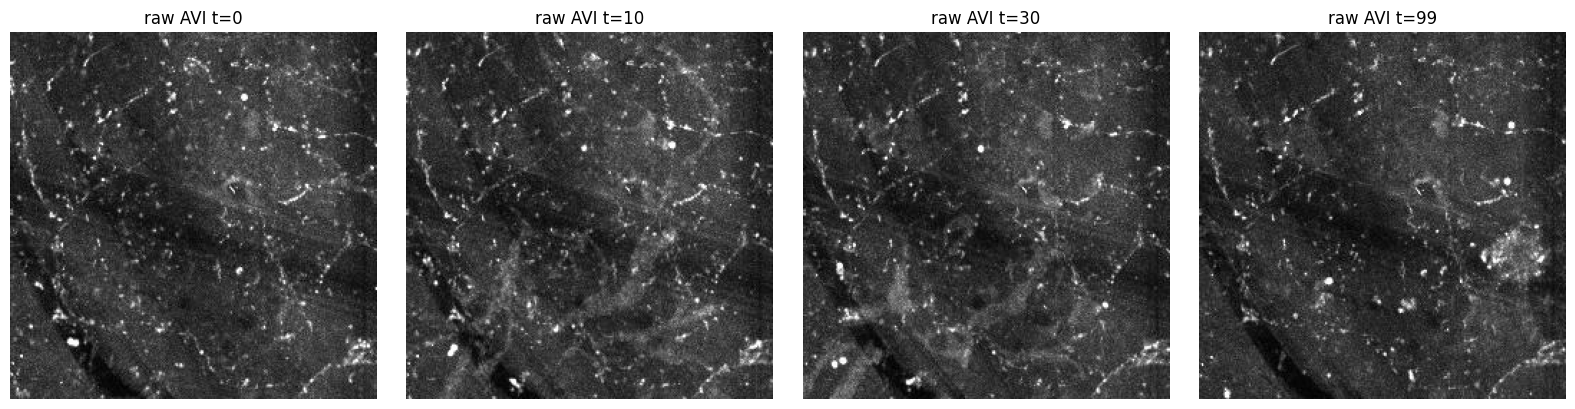

In [8]:
def show_frames(arr: np.ndarray, frames=(0, 10, 20, -1), title: str = ""):
    T = arr.shape[0]
    idxs = []
    for f in frames:
        idxs.append(T + f if f < 0 else min(f, T - 1))

    fig, axs = plt.subplots(1, len(idxs), figsize=(4 * len(idxs), 4))
    if len(idxs) == 1:
        axs = [axs]

    for ax, t in zip(axs, idxs):
        frame = arr[t]

        # Fix for arrays like (C, H, W)
        if frame.ndim == 3:
            # show first channel
            frame = frame[0]

        ax.imshow(frame, cmap="gray")
        ax.set_title(f"{title} t={t}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

# quick sanity check on one dataset
demo_name = "mixin_test44"
raw_demo = load_raw_movie(demo_name)

print(raw_demo.shape, raw_demo.min(), raw_demo.max())
show_frames(raw_demo, frames=(0, 10, 30, -1), title="raw AVI")

mixin_test57 raw shape: (400, 256, 256) min/max: 0.0 255.0


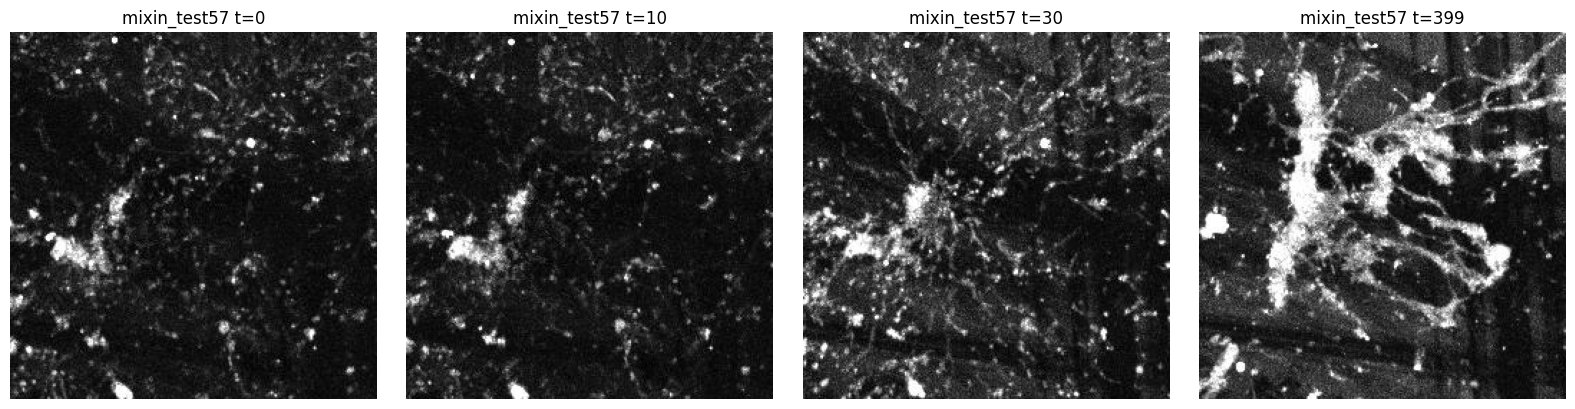

In [9]:
demo_name = "mixin_test57"
raw_demo = load_raw_movie(demo_name, use_format="avi")
print(demo_name, "raw shape:", raw_demo.shape, "min/max:", raw_demo.min(), raw_demo.max())
show_frames(raw_demo, frames=(0, 10, 30, -1), title=demo_name)

mixin_test64 raw shape: (200, 256, 256) min/max: 0.0 255.0


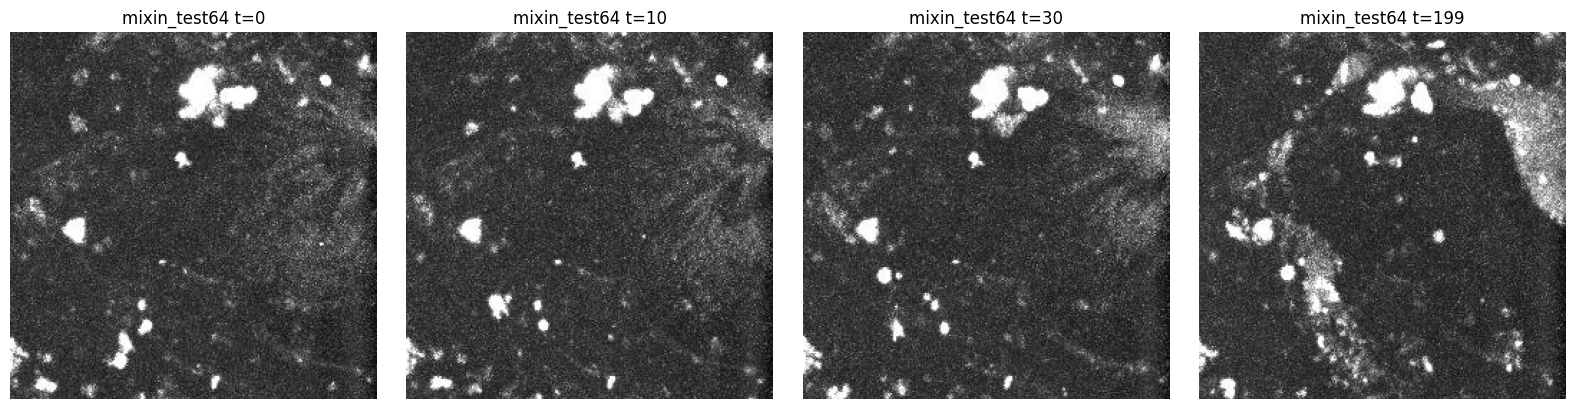

In [10]:
demo_name = "mixin_test64"
raw_demo = load_raw_movie(demo_name, use_format="avi")
print(demo_name, "raw shape:", raw_demo.shape, "min/max:", raw_demo.min(), raw_demo.max())
show_frames(raw_demo, frames=(0, 10, 30, -1), title=demo_name)

preprocessed shape: (200, 256, 256) min/max: 0.0 1.0


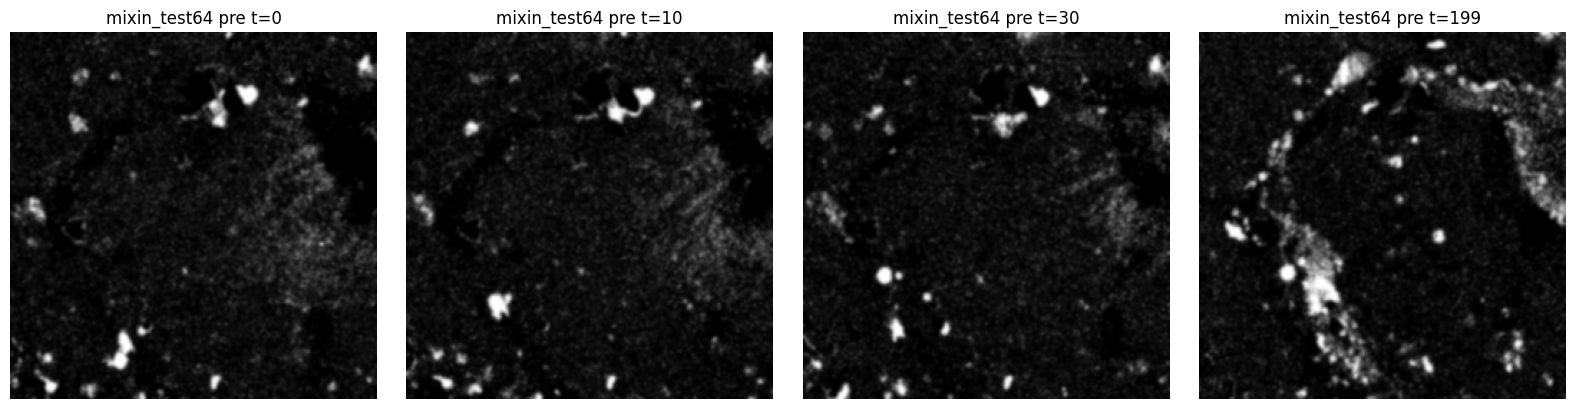

In [11]:
def preprocess_stack(
    arr: np.ndarray,
    clip_low: float = 1.0,
    clip_high: float = 99.0,
    apply_gaussian: bool = True,
    sigma: float = 1.0
) -> np.ndarray:
    """
    Basic preprocessing:
    - subtract temporal median (background)
    - clip by percentiles
    - normalize to [0, 1]
    - optional Gaussian smoothing
    """
    arr = arr.astype(np.float32)

    # subtract temporal median background
    bg = np.median(arr, axis=0)
    arr = arr - bg[None, ...]
    arr[arr < 0] = 0

    # clip by percentiles to minimize extreme noise
    lo = np.percentile(arr, clip_low)
    hi = np.percentile(arr, clip_high)
    if hi > lo:
        arr = np.clip((arr - lo) / (hi - lo), 0, 1)
    else:
        arr = np.clip(arr, 0, 1)

    if apply_gaussian:
        for t in range(arr.shape[0]):
            arr[t] = gaussian(arr[t], sigma=sigma, preserve_range=True)

    return arr.astype(np.float32)


# visualize preprocessed version of one dataset
pre_demo = preprocess_stack(raw_demo)
print("preprocessed shape:", pre_demo.shape, "min/max:", pre_demo.min(), pre_demo.max())
show_frames(pre_demo, frames=(0, 10, 30, -1), title=demo_name + " pre")

Estimated center (row, col): (141.15646937472403, 123.05742871290668)


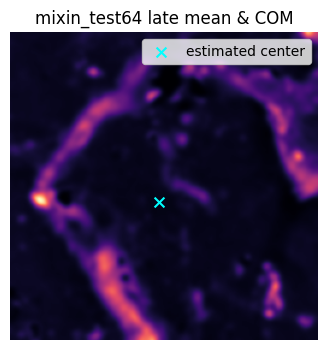

In [12]:
def estimate_aggregation_center(
    arr: np.ndarray,
    tail_fraction: float = 0.20,
    smooth_sigma: float = 2.0,
    threshold_percentile: float = 90.0
) -> Tuple[Tuple[float, float], np.ndarray]:
    """
    Estimate aggregation center from late frames:
    - average last tail_fraction of frames
    - Gaussian smoothing
    - threshold high-intensity region
    - compute intensity-weighted center of mass

    Returns:
        (row, col), heatmap_used_for_estimation
    """
    T, H, W = arr.shape
    start = int(T * (1 - tail_fraction))
    tail = arr[start:]
    mean_tail = tail.mean(axis=0)

    # smooth
    smoothed = gaussian(mean_tail, sigma=smooth_sigma, preserve_range=True)

    # threshold to focus on bright region
    thr = np.percentile(smoothed, threshold_percentile)
    mask = smoothed.copy()
    mask[mask < thr] = 0

    if mask.sum() <= 0:
        # fall back to overall COM
        com = center_of_mass(smoothed)
    else:
        com = center_of_mass(mask)

    return (float(com[0]), float(com[1])), smoothed


# example: estimate GT center for demo dataset
center_demo, heat_demo = estimate_aggregation_center(pre_demo)
print("Estimated center (row, col):", center_demo)

plt.figure(figsize=(5, 4))
plt.imshow(heat_demo, cmap="magma")
plt.scatter(center_demo[1], center_demo[0], c="cyan", s=50, marker="x", label="estimated center")
plt.title(demo_name + " late mean & COM")
plt.legend()
plt.axis("off")
plt.show()

In [13]:
def make_frame_split(T):
    split = np.array(["unused"] * T, dtype=object)

    # val: 60%–80%
    val_start = int(0.6 * T)
    val_end   = int(0.8 * T)
    split[val_start:val_end] = "val"

    # test: 80%–100%
    split[val_end:] = "test"

    return split

## Dataset

In [14]:
class DictyCenterDataset(Dataset):
    def __init__(self, pre, center_rc, K, split_array, role):
        self.pre = pre
        self.K = K
        self.samples = []

        T, H, W = pre.shape
        row_pix, col_pix = center_rc
        self.label = torch.tensor([row_pix/H, col_pix/W], dtype=torch.float32)

        if role == "train":
            t_end = min(K - 1,int(0.6*T))
            self.samples.append((0, t_end))

        # VAL / TEST
        for t_end in range(K-1, T):
            if split_array[t_end] == role:
                t_start = t_end - K + 1
                self.samples.append((t_start, t_end))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        t_start, t_end = self.samples[idx]
        window = torch.tensor(self.pre[t_start:t_end+1], dtype=torch.float32)
        return window, self.label


## Model

In [15]:
class CNN2DRegressor(nn.Module):
    """
    2D CNN with time-as-channels:
    input: (B, K, H, W)
    output: (B, 2) normalized center (row_norm, col_norm) in [0,1]
    """
    def __init__(self, in_channels: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 16, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 2),
            nn.Sigmoid(),  # normalized output [0,1]
        )

    def forward(self, x):
        feat = self.features(x)
        pooled = self.pool(feat)
        out = self.head(pooled)
        return out


class CNN3DRegressor(nn.Module):
    """
    3D CNN over time × space:
    input: (B, 1, K, H, W)
    output: (B, 2) normalized center
    """
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv3d(1, 8, (3, 3, 3), padding=1),
            nn.ReLU(),
            nn.Conv3d(8, 16, (3, 3, 3), padding=1),
            nn.ReLU(),
            nn.Conv3d(16, 32, (3, 3, 3), padding=1),
            nn.ReLU(),
        )
        self.pool = nn.AdaptiveAvgPool3d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 2),
            nn.Sigmoid(),
        )

    def forward(self, x):
        feat = self.features(x)
        pooled = self.pool(feat)
        out = self.head(pooled)
        return out


def baseline_center_of_mass(x_batch: torch.Tensor) -> torch.Tensor:
    """
    Baseline model: for each sample,
    - average the K frames → (H,W)
    - compute COM → (row_norm, col_norm)

    x_batch: (B,K,H,W)
    return:  (B,2) normalized center
    """
    B, K, H, W = x_batch.shape
    x_np = x_batch.detach().cpu().numpy()
    preds = []
    for b in range(B):
        mean_img = x_np[b].mean(axis=0)
        com = center_of_mass(mean_img)
        r, c = com
        preds.append([r / H, c / W])
    return torch.tensor(preds, dtype=torch.float32, device=x_batch.device)


## training

In [16]:
def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int = 20,
    lr: float = 1e-3,
    verbose: bool = True,
) -> nn.Module:
    model = model.to(DEVICE)
    optim = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    best_val = float("inf")
    best_state = None
    loss_curve = []

    for ep in range(epochs):
        model.train()
        train_losses = []
        for x, y in train_loader:
            x = x.to(DEVICE)          # (B,K,H,W)
            y = y.to(DEVICE)          # (B,2)

            if isinstance(model, CNN3DRegressor):
                x_in = x.unsqueeze(1)  # (B,1,K,H,W)
            else:
                x_in = x              # (B,K,H,W)

            pred = model(x_in)
            loss = loss_fn(pred, y)

            optim.zero_grad()
            loss.backward()
            optim.step()
            train_losses.append(loss.item())
        mean_tr = np.mean(train_losses)
        loss_curve.append(mean_tr)

        model.eval()
        val_losses = []
        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(DEVICE)
                y = y.to(DEVICE)

                if isinstance(model, CNN3DRegressor):
                    x_in = x.unsqueeze(1)
                else:
                    x_in = x

                pred = model(x_in)
                loss = loss_fn(pred, y)
                val_losses.append(loss.item())

        mean_tr = np.mean(train_losses)
        mean_val = np.mean(val_losses)
        if verbose:
            print(f"Epoch {ep+1}/{epochs} - train {mean_tr:.4f}  val {mean_val:.4f}")

        if mean_val < best_val:
            best_val = mean_val
            best_state = model.state_dict()

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, loss_curve


def center_error_pixels(
    y_true_norm: np.ndarray,
    y_pred_norm: np.ndarray,
    H: int,
    W: int,
) -> np.ndarray:
    """
    y_true_norm, y_pred_norm: (N,2) normalized [0,1] rows (row_norm, col_norm)
    returns: per-sample Euclidean error in pixels
    """
    true_rc = np.stack([y_true_norm[:,0]*H, y_true_norm[:,1]*W], axis=-1)
    pred_rc = np.stack([y_pred_norm[:,0]*H, y_pred_norm[:,1]*W], axis=-1)
    diff = true_rc - pred_rc
    err = np.sqrt((diff**2).sum(axis=-1))
    return err


def mean_ci(values: np.ndarray, alpha: float = 0.05) -> Tuple[float, float]:
    """
    Mean ± CI (normal approximation).
    """
    values = np.asarray(values, dtype=float)
    m = values.mean()
    s = values.std(ddof=1) if len(values) > 1 else 0.0
    z = 1.96  # 95% CI
    ci = z * s / math.sqrt(max(len(values), 1))
    return m, ci

In [17]:
def remove_black_frames(arr, thr=1e-3, verbose=True):
    """
    Remove frames that are nearly completely black.

    arr: numpy array (T, H, W)
    thr: mean pixel threshold; frames below this mean are removed
    """
    if arr.ndim != 3:
        raise ValueError(f"remove_black_frames expects (T,H,W), got {arr.shape}")

    # Compute mean brightness of each frame
    frame_means = arr.mean(axis=(1, 2))

    # Frames with brightness > threshold
    good_idx = np.where(frame_means > thr)[0]

    cleaned = arr[good_idx]

    if verbose:
        removed = len(arr) - len(cleaned)
        print(f"[remove_black_frames] Removed {removed} black frames "
              f"({removed/len(arr)*100:.1f}%). Remaining frames: {len(cleaned)}")

    return cleaned

In [18]:
def get_pixel_size(dataset_name):
    return EXPERIMENT_INFO[dataset_name]["pixel_size_um"]


def eval_dataset_one_model(
    dataset_name: str,
    K: int,
    model_type: str = "cnn2d",
    epochs: int = 20,
    batch_size: int = 16,
    downsample_factor: float = 2.0,
    print_loss_graph: bool = False,
):

    # 1. Load and preprocess
    raw = load_raw_movie(dataset_name, use_format="avi")
    pre = preprocess_stack(raw)
    center_rc, _ = estimate_aggregation_center(pre)

    T, H, W = pre.shape
    split_array = make_frame_split(T)

    errors_pix_all = []
    errors_pix_ds_all = []
    loss_curves = {}

    for seed in SEEDS:
        set_seed(seed)
        tr_ds = DictyCenterDataset(pre, center_rc, K, split_array, role="train")
        val_ds = DictyCenterDataset(pre, center_rc, K, split_array, role="val")
        te_ds = DictyCenterDataset(pre, center_rc, K, split_array, role="test")

        tr_loader = DataLoader(tr_ds, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
        te_loader = DataLoader(te_ds, batch_size=batch_size, shuffle=False)

        # 3. Build model
        if model_type == "cnn2d":
            model = CNN2DRegressor(in_channels=K)
        else:
            model = CNN3DRegressor()

        # 4. Train
        model, loss_curve = train_model(model, tr_loader, val_loader,
                                        epochs=epochs, lr=1e-3, verbose=False)
        loss_curves[seed] = loss_curve

        # 5. Evaluate (full resolution)
        model.eval()
        all_true = []
        all_pred = []

        with torch.no_grad():
            for x, y in te_loader:
                x = x.to(DEVICE)
                y = y.to(DEVICE)
                x_in = x.unsqueeze(1) if isinstance(model, CNN3DRegressor) else x
                pred = model(x_in)
                all_true.append(y.cpu().numpy())
                all_pred.append(pred.cpu().numpy())

        all_true = np.concatenate(all_true)
        all_pred = np.concatenate(all_pred)
        err_pix = center_error_pixels(all_true, all_pred, H, W)
        errors_pix_all.extend(err_pix.tolist())

        # 6. Resolution robustness test
        if downsample_factor > 1.0:
            all_true_ds = []
            all_pred_ds = []
            with torch.no_grad():
                for x, y in te_loader:
                    x = x.to(DEVICE)
                    y = y.to(DEVICE)
                    B,K_,H0,W0 = x.shape
                    x_rs = x.view(B*K_, 1, H0, W0)
                    x_small = F.interpolate(
                        x_rs,
                        scale_factor=1.0/downsample_factor,
                        mode="bilinear",
                        align_corners=False
                    )
                    _,_,Hs,Ws = x_small.shape
                    x_small = x_small.view(B, K_, Hs, Ws)

                    x_in = x_small.unsqueeze(1) if isinstance(model, CNN3DRegressor) else x_small
                    pred_ds = model(x_in)
                    all_true_ds.append(y.cpu().numpy())
                    all_pred_ds.append(pred_ds.cpu().numpy())
            all_true_ds = np.concatenate(all_true_ds)
            all_pred_ds = np.concatenate(all_pred_ds)
            err_pix_ds = center_error_pixels(all_true_ds, all_pred_ds, H, W)
            errors_pix_ds_all.extend(err_pix_ds.tolist())

    # 7. Plot loss
    if print_loss_graph:
        plt.figure(figsize=(6,4))
        for seed, curve in loss_curves.items():
            plt.plot(curve, label=f"seed={seed}")
        plt.title(f"Loss Curve ({model_type}, K={K}, {dataset_name})")
        plt.xlabel("Epoch")
        plt.ylabel("MSE Loss")
        plt.grid()
        plt.legend()
        plt.show()

    # 8. Convert to um
    px_um = get_pixel_size(dataset_name)
    errors_um = np.array(errors_pix_all) * px_um
    errors_um_ds = np.array(errors_pix_ds_all) * px_um

    return errors_um, errors_um_ds, (H, W)


In [19]:
def eval_baseline_com(dataset_name: str, K: int):

    raw = load_raw_movie(dataset_name, use_format="avi")
    pre = preprocess_stack(raw)
    center_rc, _ = estimate_aggregation_center(pre)

    T, H, W = pre.shape
    split_array = make_frame_split(T)

    errors_pix_all = []

    for seed in SEEDS:
        set_seed(seed)

        te_ds = DictyCenterDataset(pre, center_rc, K, split_array, role="test")
        te_loader = DataLoader(te_ds, batch_size=32, shuffle=False)

        all_true = []
        all_pred = []

        for x, y in te_loader:
            pred = baseline_center_of_mass(x)
            all_true.append(y.numpy())
            all_pred.append(pred.cpu().numpy())

        if len(all_true) == 0:
            continue

        all_true = np.concatenate(all_true)
        all_pred = np.concatenate(all_pred)
        err_pix = center_error_pixels(all_true, all_pred, H, W)
        errors_pix_all.extend(err_pix)

    px_um = get_pixel_size(dataset_name)
    return np.array(errors_pix_all) * px_um, (H, W)


## Error vs. available frames

In [20]:
print("Frame Count for Each Dataset:")
for dataset_name in DATASETS.keys():
    raw = load_raw_movie(dataset_name, use_format="avi")
    print(f"{dataset_name}:  T = {raw.shape[0]}")


Frame Count for Each Dataset:
mixin_test44:  T = 100
mixin_test57:  T = 400
mixin_test64:  T = 200


In [21]:
K_LISTS = {
    "mixin_test44": [2, 4, 8, 15, 50],
    "mixin_test57": [5, 10, 20, 40, 80],
    "mixin_test64": [4, 8, 15, 30, 60],
}



>>> Dataset=mixin_test44, K=2, model=baseline_com

>>> Dataset=mixin_test44, K=2, model=cnn2d


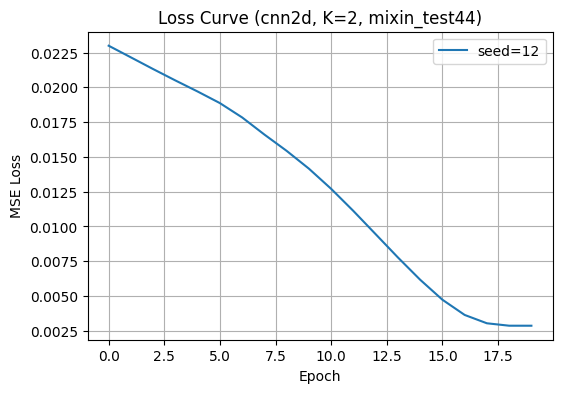

dataset: mixin_test44, K: 2, mmodel: cnn2d, ean_center_error_um: 40.15502120780945, drop: -1.600965607410653

>>> Dataset=mixin_test44, K=2, model=cnn3d


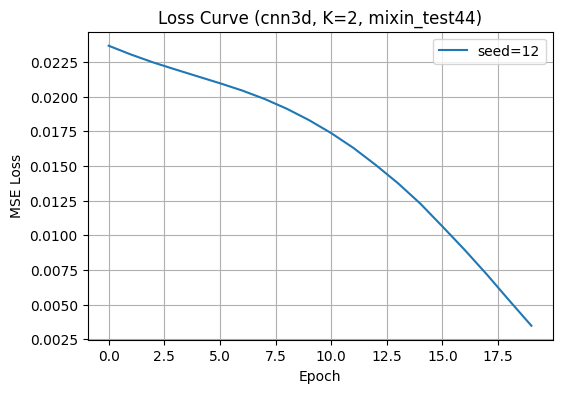

dataset: mixin_test44, K: 2, model: cnn3d, mean_center_error_um: 39.82739965152741, drop%: 1.3317053014914941

>>> Dataset=mixin_test44, K=4, model=baseline_com

>>> Dataset=mixin_test44, K=4, model=cnn2d


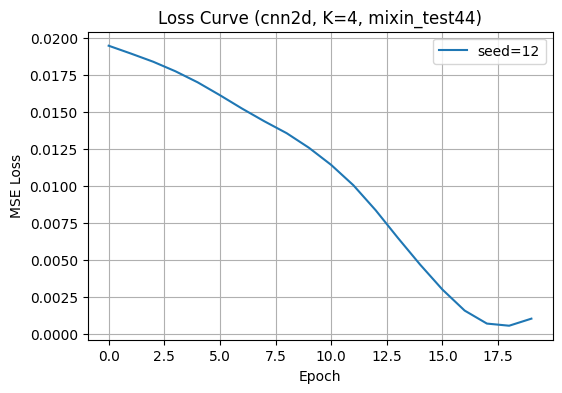

dataset: mixin_test44, K: 4, mmodel: cnn2d, ean_center_error_um: 25.764628960609436, drop: -4.696607538872083

>>> Dataset=mixin_test44, K=4, model=cnn3d


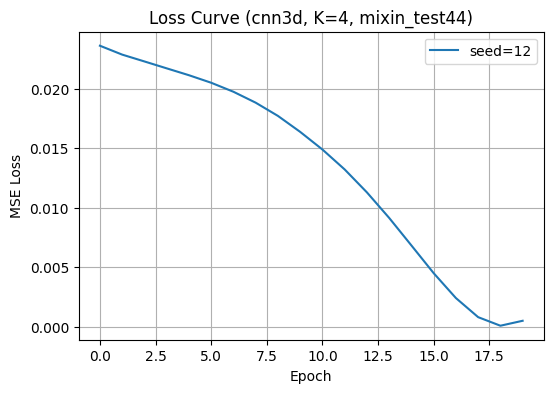

dataset: mixin_test44, K: 4, model: cnn3d, mean_center_error_um: 29.73057709741593, drop%: -3.7421384378317573

>>> Dataset=mixin_test44, K=8, model=baseline_com

>>> Dataset=mixin_test44, K=8, model=cnn2d


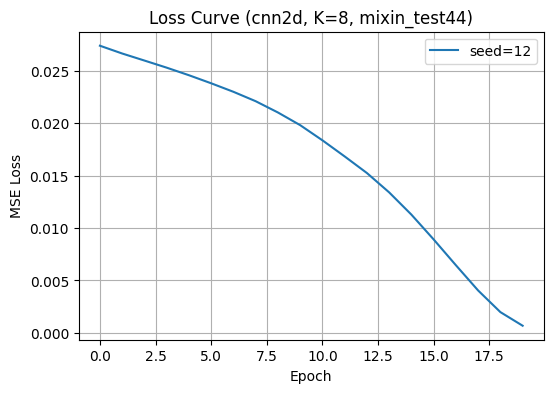

dataset: mixin_test44, K: 8, mmodel: cnn2d, ean_center_error_um: 20.894055035591123, drop: 3.309199128316977

>>> Dataset=mixin_test44, K=8, model=cnn3d


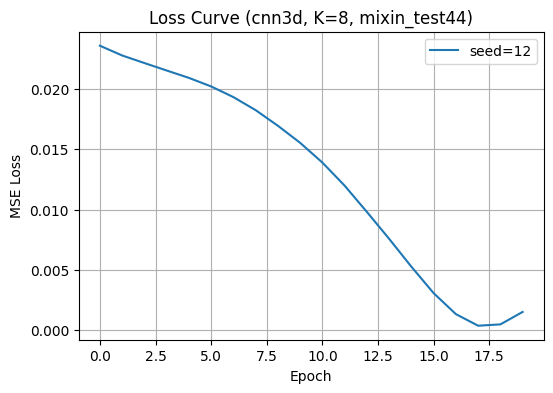

dataset: mixin_test44, K: 8, model: cnn3d, mean_center_error_um: 36.51606430339813, drop%: -3.1676631926020606

>>> Dataset=mixin_test44, K=15, model=baseline_com

>>> Dataset=mixin_test44, K=15, model=cnn2d


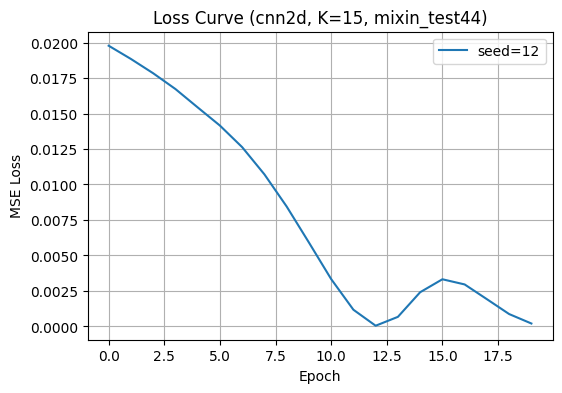

dataset: mixin_test44, K: 15, mmodel: cnn2d, ean_center_error_um: 21.119070492982864, drop: 3.7395200440798724

>>> Dataset=mixin_test44, K=15, model=cnn3d


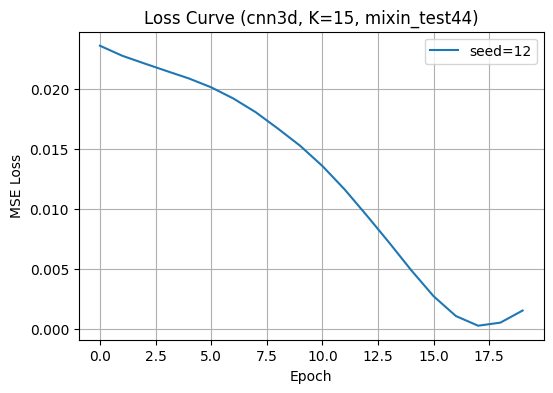

dataset: mixin_test44, K: 15, model: cnn3d, mean_center_error_um: 33.000687769413, drop%: -3.545395852196929

>>> Dataset=mixin_test44, K=50, model=baseline_com

>>> Dataset=mixin_test44, K=50, model=cnn2d


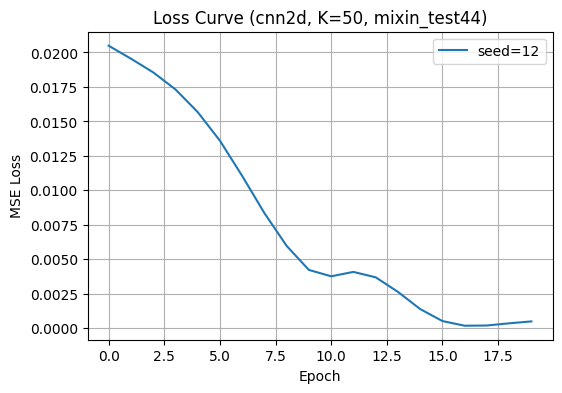

dataset: mixin_test44, K: 50, mmodel: cnn2d, ean_center_error_um: 32.398107556819916, drop: 2.0890767560266292

>>> Dataset=mixin_test44, K=50, model=cnn3d


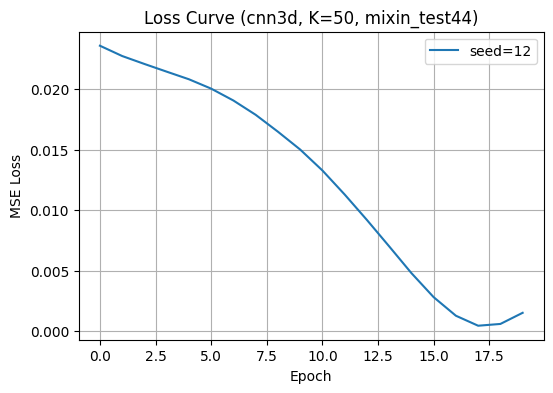

dataset: mixin_test44, K: 50, model: cnn3d, mean_center_error_um: 37.845913825511936, drop%: -2.892871749225021

>>> Dataset=mixin_test57, K=5, model=baseline_com

>>> Dataset=mixin_test57, K=5, model=cnn2d


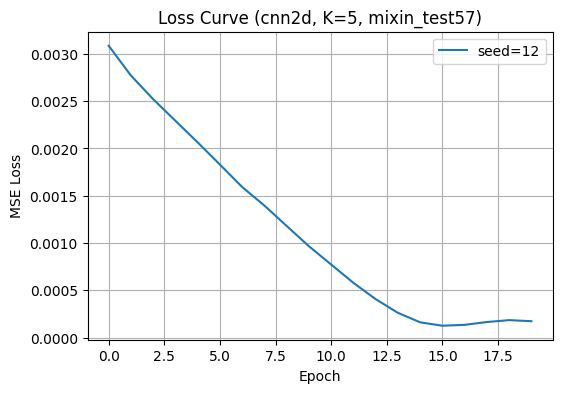

dataset: mixin_test57, K: 5, mmodel: cnn2d, ean_center_error_um: 32.27428005576134, drop: -0.9338458025869845

>>> Dataset=mixin_test57, K=5, model=cnn3d


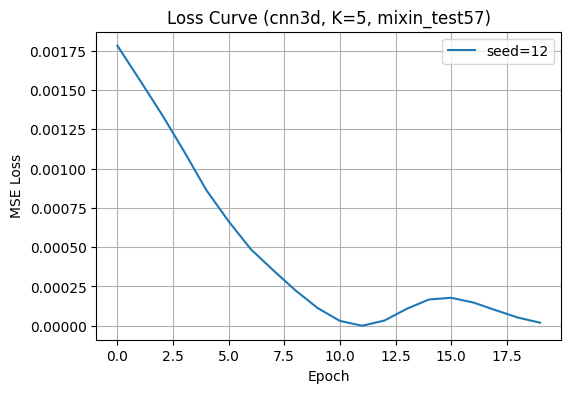

dataset: mixin_test57, K: 5, model: cnn3d, mean_center_error_um: 4.776534916043282, drop%: -1.7790835053032126

>>> Dataset=mixin_test57, K=10, model=baseline_com

>>> Dataset=mixin_test57, K=10, model=cnn2d


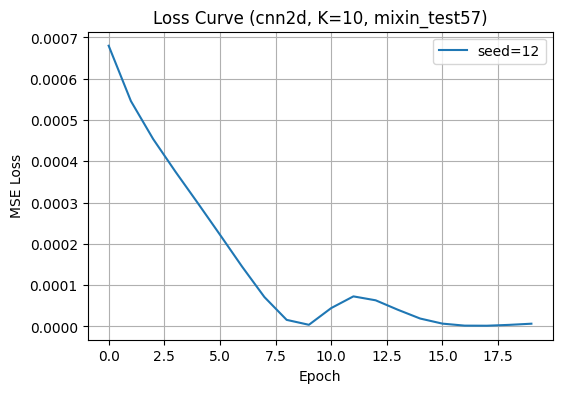

dataset: mixin_test57, K: 10, mmodel: cnn2d, ean_center_error_um: 1.0321540961675346, drop: 5.149518878925673

>>> Dataset=mixin_test57, K=10, model=cnn3d


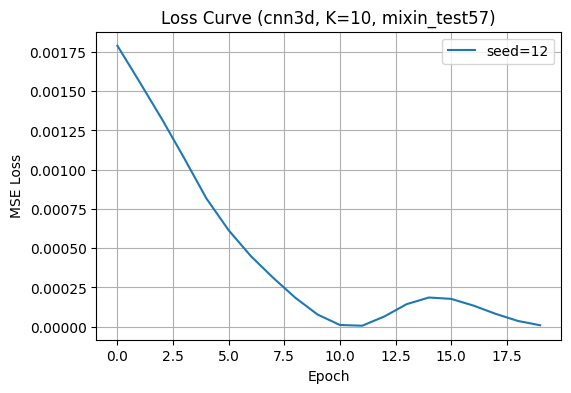

dataset: mixin_test57, K: 10, model: cnn3d, mean_center_error_um: 3.49635310266912, drop%: -2.313478969448176

>>> Dataset=mixin_test57, K=20, model=baseline_com

>>> Dataset=mixin_test57, K=20, model=cnn2d


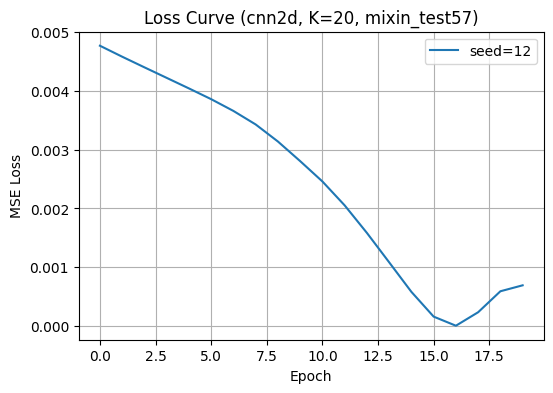

dataset: mixin_test57, K: 20, mmodel: cnn2d, ean_center_error_um: 120.50770822334292, drop: -0.808001425262835

>>> Dataset=mixin_test57, K=20, model=cnn3d


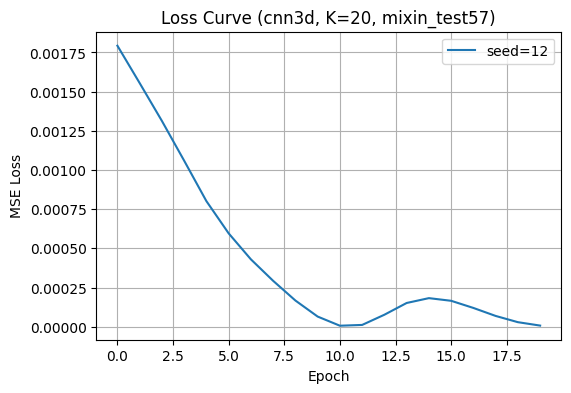

dataset: mixin_test57, K: 20, model: cnn3d, mean_center_error_um: 3.2879230820536613, drop%: -2.2191229828701826

>>> Dataset=mixin_test57, K=40, model=baseline_com

>>> Dataset=mixin_test57, K=40, model=cnn2d


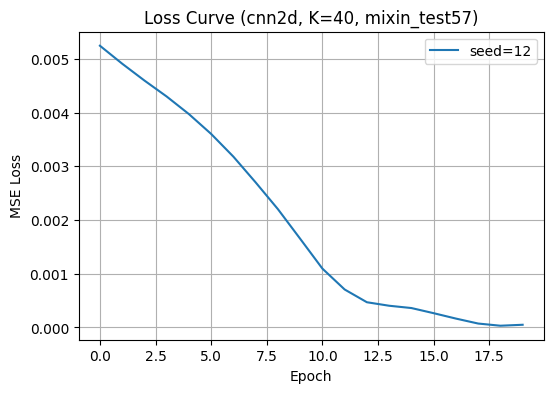

dataset: mixin_test57, K: 40, mmodel: cnn2d, ean_center_error_um: 59.30935065579415, drop: -0.8412488357098972

>>> Dataset=mixin_test57, K=40, model=cnn3d


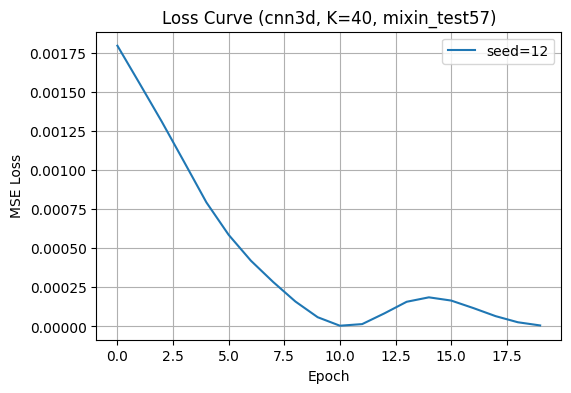

dataset: mixin_test57, K: 40, model: cnn3d, mean_center_error_um: 2.988599065922201, drop%: -2.4287560887819266

>>> Dataset=mixin_test57, K=80, model=baseline_com

>>> Dataset=mixin_test57, K=80, model=cnn2d


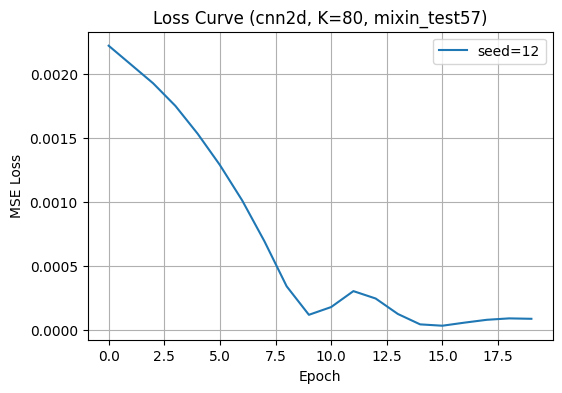

dataset: mixin_test57, K: 80, mmodel: cnn2d, ean_center_error_um: 22.750021713733673, drop: -0.40237415915451774

>>> Dataset=mixin_test57, K=80, model=cnn3d


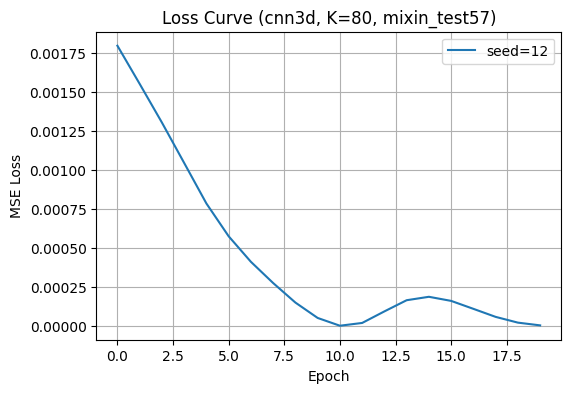

dataset: mixin_test57, K: 80, model: cnn3d, mean_center_error_um: 2.3128130148425696, drop%: -2.8791791674860274

>>> Dataset=mixin_test64, K=4, model=baseline_com

>>> Dataset=mixin_test64, K=4, model=cnn2d


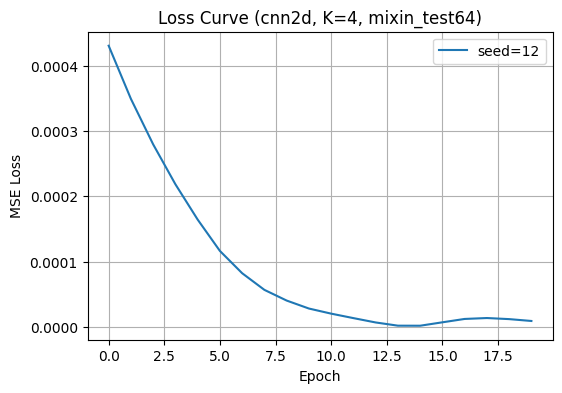

dataset: mixin_test64, K: 4, mmodel: cnn2d, ean_center_error_um: 1.4473808517456055, drop: -2.4572850119373313

>>> Dataset=mixin_test64, K=4, model=cnn3d


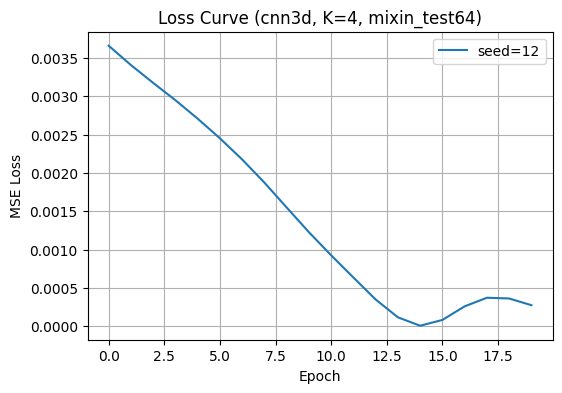

dataset: mixin_test64, K: 4, model: cnn3d, mean_center_error_um: 7.148396667480469, drop%: -2.783421594168776

>>> Dataset=mixin_test64, K=8, model=baseline_com

>>> Dataset=mixin_test64, K=8, model=cnn2d


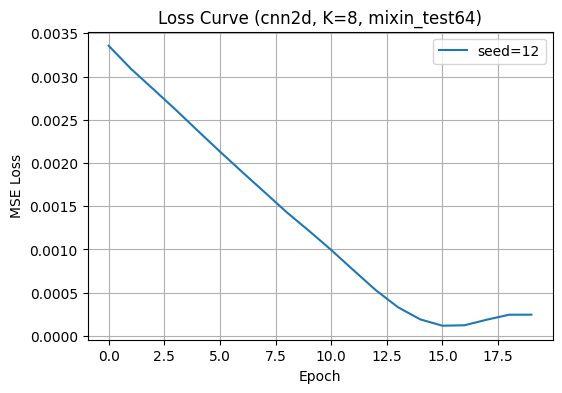

dataset: mixin_test64, K: 8, mmodel: cnn2d, ean_center_error_um: 9.748288055419923, drop: -2.7497674520005733

>>> Dataset=mixin_test64, K=8, model=cnn3d


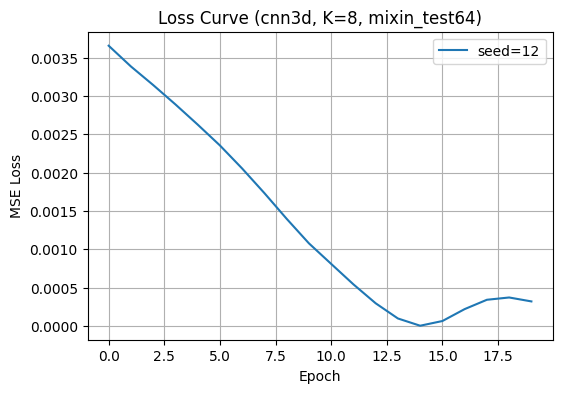

dataset: mixin_test64, K: 8, model: cnn3d, mean_center_error_um: 8.321843200683592, drop%: -2.685199588318075

>>> Dataset=mixin_test64, K=15, model=baseline_com

>>> Dataset=mixin_test64, K=15, model=cnn2d


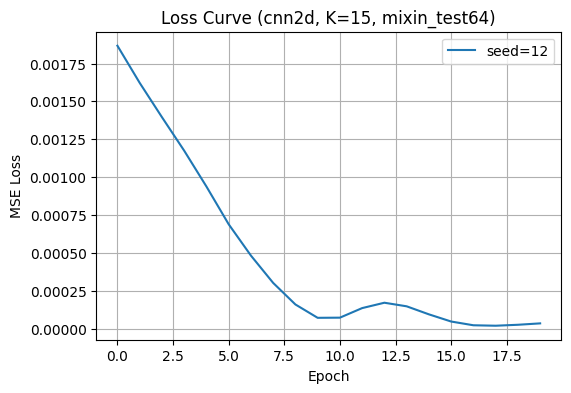

dataset: mixin_test64, K: 15, mmodel: cnn2d, ean_center_error_um: 2.3806722450256346, drop: 1.5546563584195168

>>> Dataset=mixin_test64, K=15, model=cnn3d


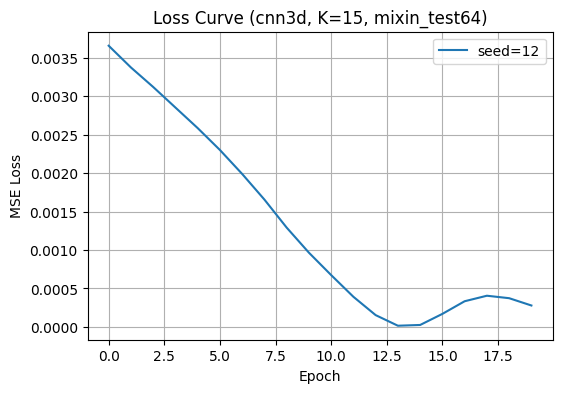

dataset: mixin_test64, K: 15, model: cnn3d, mean_center_error_um: 7.281650680541992, drop%: -2.955006254381454

>>> Dataset=mixin_test64, K=30, model=baseline_com

>>> Dataset=mixin_test64, K=30, model=cnn2d


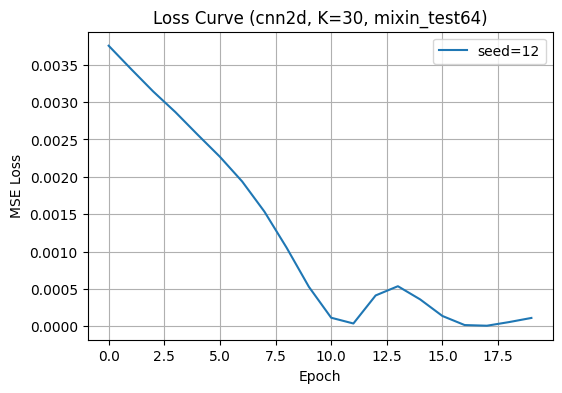

dataset: mixin_test64, K: 30, mmodel: cnn2d, ean_center_error_um: 2.824446964263916, drop: 5.632458935944195

>>> Dataset=mixin_test64, K=30, model=cnn3d


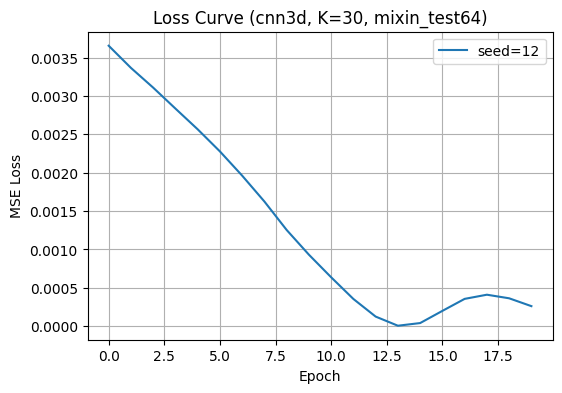

dataset: mixin_test64, K: 30, model: cnn3d, mean_center_error_um: 6.900023544311523, drop%: -3.0943522255154257

>>> Dataset=mixin_test64, K=60, model=baseline_com

>>> Dataset=mixin_test64, K=60, model=cnn2d


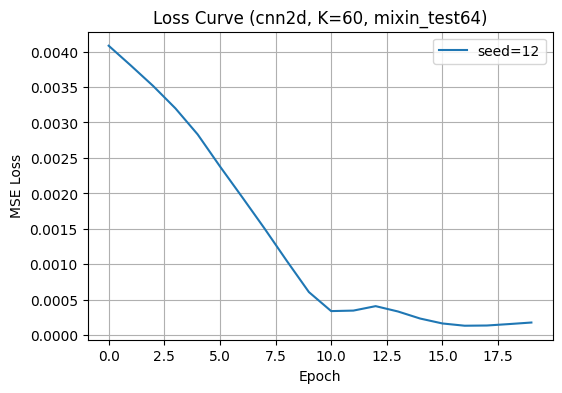

dataset: mixin_test64, K: 60, mmodel: cnn2d, ean_center_error_um: 5.585470794677735, drop: 0.2080451356766689

>>> Dataset=mixin_test64, K=60, model=cnn3d


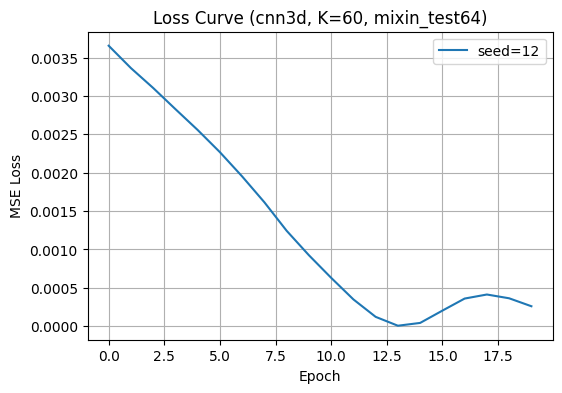

dataset: mixin_test64, K: 60, model: cnn3d, mean_center_error_um: 6.7371015472412115, drop%: -3.178891462037161


,dataset,K,model,mean_center_error_um,ci_center_error_um,n_samples,resolution_robust_drop_%
0,mixin_test44,2,baseline_com,79.764520,3.826797,20,NaN
1,mixin_test44,2,cnn2d,40.155021,0.125329,20,-1.600966
2,mixin_test44,2,cnn3d,39.827400,0.069250,20,1.331705
3,mixin_test44,4,baseline_com,81.647143,4.486012,20,NaN
4,mixin_test44,4,cnn2d,25.764629,0.256251,20,-4.696608
5,mixin_test44,4,cnn3d,29.730577,0.188193,20,-3.742138
6,mixin_test44,8,baseline_com,85.649755,5.482649,20,NaN
7,mixin_test44,8,cnn2d,20.894055,0.345306,20,3.309199
8,mixin_test44,8,cnn3d,36.516064,0.210977,20,-3.167663
9,mixin_test44,15,baseline_com,92.807580,5.836659,20,NaN


In [22]:
MODEL_TYPES = ["baseline_com", "cnn2d", "cnn3d"]
results_records = []
SEEDS = [12]

for dataset_name in DATASETS.keys():

    K_LIST = K_LISTS[dataset_name]

    for K in K_LIST:
        print(f"\n>>> Dataset={dataset_name}, K={K}, model=baseline_com")
        errs_um_base, (H, W) = eval_baseline_com(dataset_name, K)
        mean_e, ci_e = mean_ci(errs_um_base)
        results_records.append({
            "dataset": dataset_name,
            "K": K,
            "model": "baseline_com",
            "mean_center_error_um": mean_e,
            "ci_center_error_um": ci_e,
            "n_samples": len(errs_um_base),
            "resolution_robust_drop_%": np.nan,
        })

        # CNN2D
        if "cnn2d" in MODEL_TYPES:
            print(f"\n>>> Dataset={dataset_name}, K={K}, model=cnn2d")
            errs_um_2d, errs_um_2d_ds, (H, W) = eval_dataset_one_model(
                dataset_name, K, model_type="cnn2d",
                epochs=20, batch_size=16, print_loss_graph=True
            )
            mean_e, ci_e = mean_ci(errs_um_2d)
            mean_e_ds, ci_e_ds = mean_ci(errs_um_2d_ds)
            drop_pct = 100.0 * (mean_e_ds - mean_e) / max(mean_e, 1e-8)
            print(f"dataset: {dataset_name}, K: {K}, mmodel: cnn2d, ean_center_error_um: {mean_e}, drop: {drop_pct}")

            results_records.append({
                "dataset": dataset_name,
                "K": K,
                "model": "cnn2d",
                "mean_center_error_um": mean_e,
                "ci_center_error_um": ci_e,
                "n_samples": len(errs_um_2d),
                "resolution_robust_drop_%": drop_pct,
            })

        # CNN3D
        if "cnn3d" in MODEL_TYPES:
            print(f"\n>>> Dataset={dataset_name}, K={K}, model=cnn3d")
            errs_um_3d, errs_um_3d_ds, (H, W) = eval_dataset_one_model(
                dataset_name, K, model_type="cnn3d", epochs=20, batch_size=16, print_loss_graph=True
            )
            mean_e, ci_e = mean_ci(errs_um_3d)
            mean_e_ds, ci_e_ds = mean_ci(errs_um_3d_ds)
            drop_pct = 100.0 * (mean_e_ds - mean_e) / max(mean_e, 1e-8)
            print(f"dataset: {dataset_name}, K: {K}, model: cnn3d, mean_center_error_um: {mean_e}, drop%: {drop_pct}")
            results_records.append({
                "dataset": dataset_name,
                "K": K,
                "model": "cnn3d",
                "mean_center_error_um": mean_e,
                "ci_center_error_um": ci_e,
                "n_samples": len(errs_um_3d),
                "resolution_robust_drop_%": drop_pct,
            })

results_df = pd.DataFrame(results_records)
results_df

In [23]:
import torch
torch.cuda.empty_cache()
torch.cuda.ipc_collect()


In [24]:
def plot_error_vs_K(results_df: pd.DataFrame, dataset_name: str, model: str = "cnn2d"):
    sub = results_df[(results_df["dataset"] == dataset_name) & (results_df["model"] == model)]
    sub = sub.sort_values("K")
    if sub.empty:
        print("No results for", dataset_name, model)
        return

    Ks = sub["K"].values
    mean_err = sub["mean_center_error_um"].values
    ci = sub["ci_center_error_um"].values

    plt.figure(figsize=(5,4))
    plt.errorbar(Ks, mean_err, yerr=ci, fmt="-o", capsize=4)
    plt.xlabel("Number of early frames K")
    plt.ylabel("Center error (μm)")
    plt.title(f"{dataset_name} – Error vs K ({model})")
    plt.grid(True, alpha=0.3)
    plt.show()


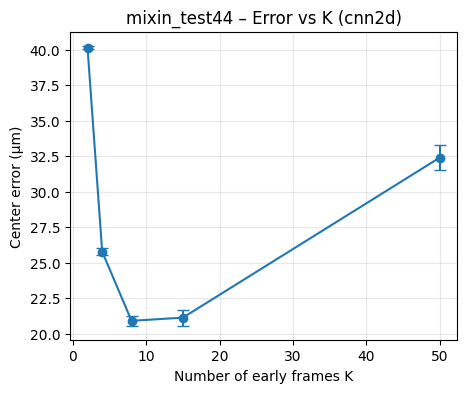

In [25]:
plot_error_vs_K(results_df, "mixin_test44", model="cnn2d")

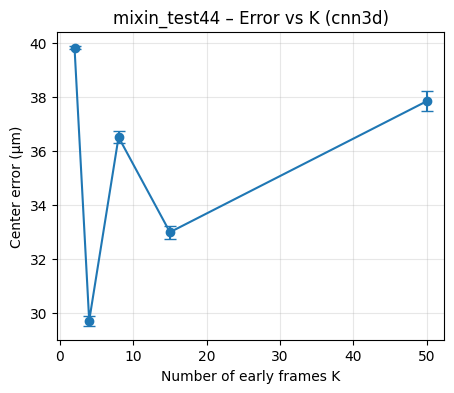

In [26]:
plot_error_vs_K(results_df, "mixin_test44", model="cnn3d")

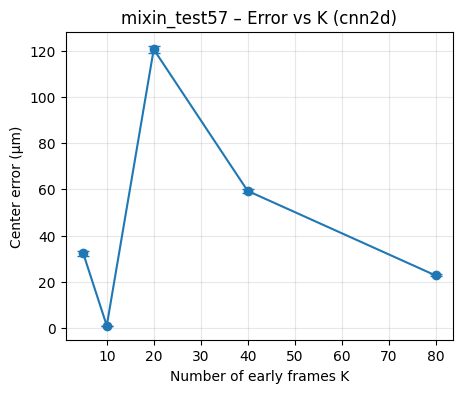

In [27]:
plot_error_vs_K(results_df, "mixin_test57", model="cnn2d")

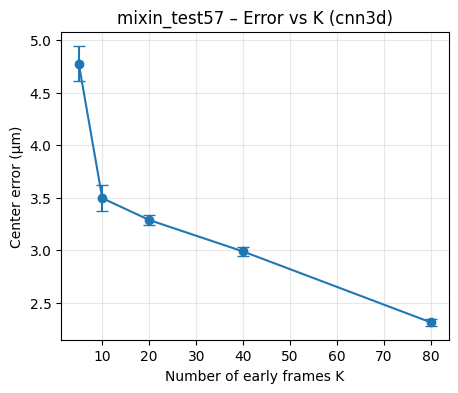

In [28]:
plot_error_vs_K(results_df, "mixin_test57", model="cnn3d")

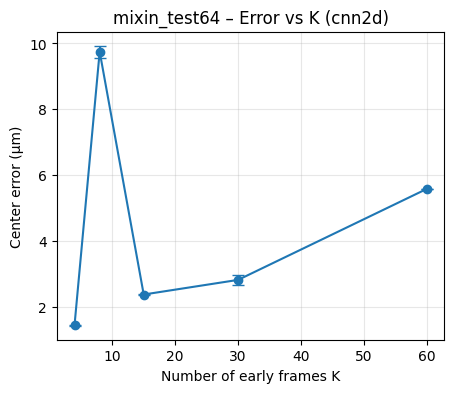

In [29]:
plot_error_vs_K(results_df, "mixin_test64", model="cnn2d")

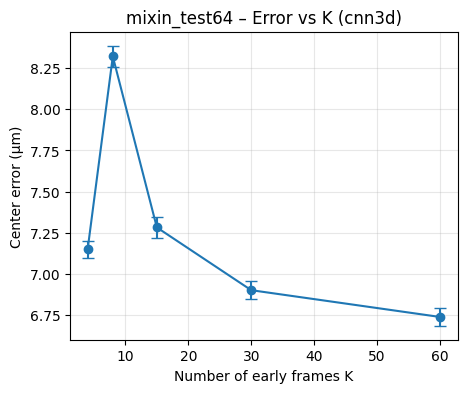

In [30]:
plot_error_vs_K(results_df, "mixin_test64", model="cnn3d")

## Robustness

In [31]:
K_LISTS = {
    "mixin_test44": [15],
    "mixin_test57": [40],
    "mixin_test64": [30],
}



>>> Dataset=mixin_test44, K=15, model=baseline_com

>>> Dataset=mixin_test44, K=15, model=cnn2d


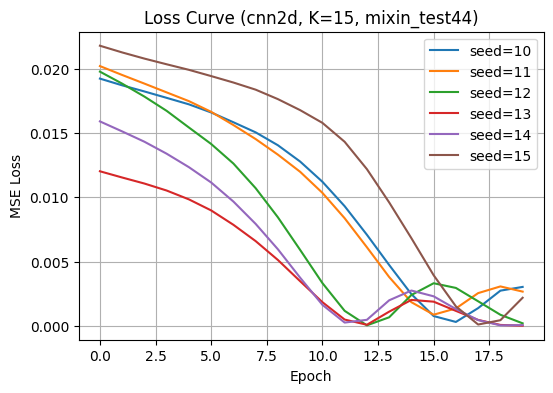

dataset: mixin_test44, K: 15, mmodel: cnn2d, ean_center_error_um: 18.57110127043724, drop: -0.311759198227066

>>> Dataset=mixin_test44, K=15, model=cnn3d


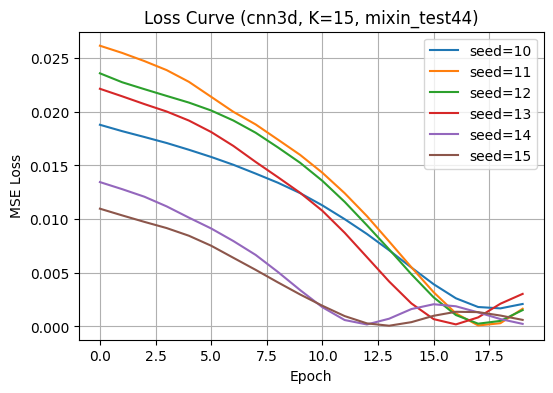

dataset: mixin_test44, K: 15, model: cnn3d, mean_center_error_um: 22.681133245527747, drop%: -3.48836341856491

>>> Dataset=mixin_test57, K=40, model=baseline_com

>>> Dataset=mixin_test57, K=40, model=cnn2d


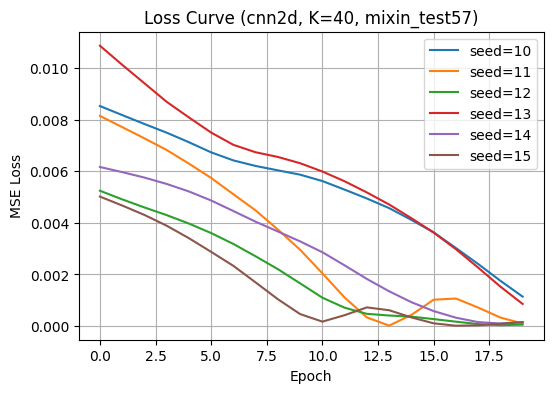

dataset: mixin_test57, K: 40, mmodel: cnn2d, ean_center_error_um: 75.42511147548755, drop: -0.7342156196437026

>>> Dataset=mixin_test57, K=40, model=cnn3d


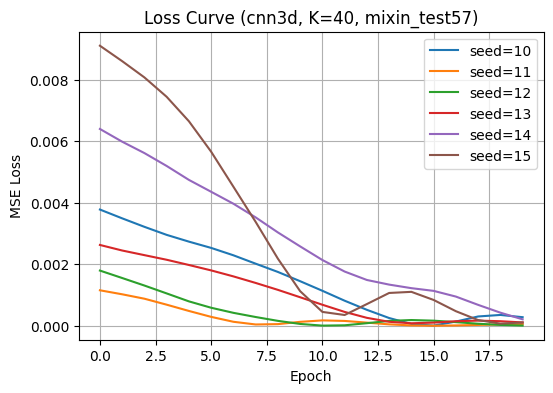

dataset: mixin_test57, K: 40, model: cnn3d, mean_center_error_um: 16.40243961135174, drop%: -1.5947107810263055

>>> Dataset=mixin_test64, K=30, model=baseline_com

>>> Dataset=mixin_test64, K=30, model=cnn2d


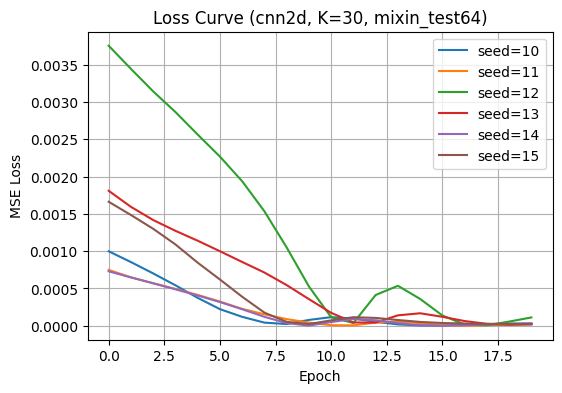

dataset: mixin_test64, K: 30, mmodel: cnn2d, ean_center_error_um: 1.8352564446131392, drop: 2.678503515990347

>>> Dataset=mixin_test64, K=30, model=cnn3d


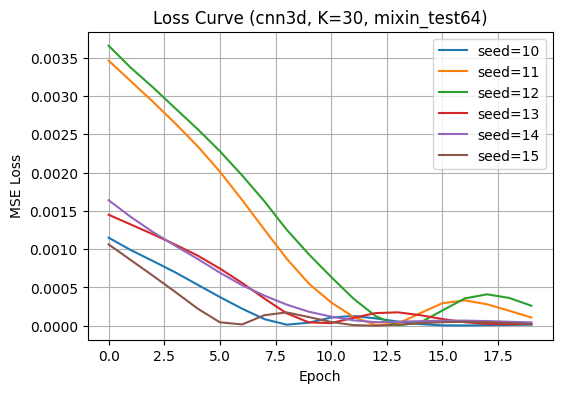

dataset: mixin_test64, K: 30, model: cnn3d, mean_center_error_um: 2.9795421953201298, drop%: -0.5907077378974885


,dataset,K,model,mean_center_error_um,ci_center_error_um,n_samples,resolution_robust_drop_%
0,mixin_test44,15,baseline_com,92.807580,2.332210,120,NaN
1,mixin_test44,15,cnn2d,18.571101,1.334316,120,-0.311759
2,mixin_test44,15,cnn3d,22.681133,2.190675,120,-3.488363
3,mixin_test57,40,baseline_com,34.595527,0.649910,480,NaN
4,mixin_test57,40,cnn2d,75.425111,2.080151,480,-0.734216
5,mixin_test57,40,cnn3d,16.402440,1.134491,480,-1.594711
6,mixin_test64,30,baseline_com,17.184885,0.216838,240,NaN
7,mixin_test64,30,cnn2d,1.835256,0.072923,240,2.678504
8,mixin_test64,30,cnn3d,2.979542,0.263070,240,-0.590708


In [33]:
MODEL_TYPES = ["baseline_com", "cnn2d", "cnn3d"]
results_records = []
SEEDS = [10,11,12,13,14,15]

for dataset_name in DATASETS.keys():

    K_LIST = K_LISTS[dataset_name]

    for K in K_LIST:
        print(f"\n>>> Dataset={dataset_name}, K={K}, model=baseline_com")
        errs_um_base, (H, W) = eval_baseline_com(dataset_name, K)
        mean_e, ci_e = mean_ci(errs_um_base)
        results_records.append({
            "dataset": dataset_name,
            "K": K,
            "model": "baseline_com",
            "mean_center_error_um": mean_e,
            "ci_center_error_um": ci_e,
            "n_samples": len(errs_um_base),
            "resolution_robust_drop_%": np.nan,
        })

        # CNN2D
        if "cnn2d" in MODEL_TYPES:
            print(f"\n>>> Dataset={dataset_name}, K={K}, model=cnn2d")
            errs_um_2d, errs_um_2d_ds, (H, W) = eval_dataset_one_model(
                dataset_name, K, model_type="cnn2d",
                epochs=20, batch_size=16, print_loss_graph=True
            )
            mean_e, ci_e = mean_ci(errs_um_2d)
            mean_e_ds, ci_e_ds = mean_ci(errs_um_2d_ds)
            drop_pct = 100.0 * (mean_e_ds - mean_e) / max(mean_e, 1e-8)
            print(f"dataset: {dataset_name}, K: {K}, mmodel: cnn2d, ean_center_error_um: {mean_e}, drop: {drop_pct}")

            results_records.append({
                "dataset": dataset_name,
                "K": K,
                "model": "cnn2d",
                "mean_center_error_um": mean_e,
                "ci_center_error_um": ci_e,
                "n_samples": len(errs_um_2d),
                "resolution_robust_drop_%": drop_pct,
            })

        # CNN3D
        if "cnn3d" in MODEL_TYPES:
            print(f"\n>>> Dataset={dataset_name}, K={K}, model=cnn3d")
            errs_um_3d, errs_um_3d_ds, (H, W) = eval_dataset_one_model(
                dataset_name, K, model_type="cnn3d", epochs=20, batch_size=16, print_loss_graph=True
            )
            mean_e, ci_e = mean_ci(errs_um_3d)
            mean_e_ds, ci_e_ds = mean_ci(errs_um_3d_ds)
            drop_pct = 100.0 * (mean_e_ds - mean_e) / max(mean_e, 1e-8)
            print(f"dataset: {dataset_name}, K: {K}, model: cnn3d, mean_center_error_um: {mean_e}, drop%: {drop_pct}")
            results_records.append({
                "dataset": dataset_name,
                "K": K,
                "model": "cnn3d",
                "mean_center_error_um": mean_e,
                "ci_center_error_um": ci_e,
                "n_samples": len(errs_um_3d),
                "resolution_robust_drop_%": drop_pct,
            })

results_df2 = pd.DataFrame(results_records)
results_df2

## Early frames with predicted center overlayed

In [38]:
def get_trained_model_for_visual(
    dataset_name: str,
    K: int,
    model_type: str = "cnn2d",
    epochs: int = 20,
    batch_size: int = 16,
):
    raw = load_raw_movie(dataset_name, use_format="avi")
    pre = preprocess_stack(raw)
    center_rc, _ = estimate_aggregation_center(pre)
    T, H, W = pre.shape

    # fair split array (train:0~60%, val:60~80%, test:80~100%)
    split_array = make_frame_split(T)

    tr_ds = DictyCenterDataset(pre, center_rc, K, split_array, role="train")
    val_ds = DictyCenterDataset(pre, center_rc, K, split_array, role="val")

    tr_loader = DataLoader(tr_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    if model_type == "cnn2d":
        model = CNN2DRegressor(in_channels=K)
    elif model_type == "cnn3d":
        model = CNN3DRegressor()
    else:
        raise ValueError("Unknown model_type")

    model, _ = train_model(model, tr_loader, val_loader,
                           epochs=epochs, lr=1e-3, verbose=False)
    model.eval()

    t_start, t_end = tr_ds.samples[0]
    early_window = torch.tensor(pre[t_start:t_end+1], dtype=torch.float32)
    x_early = early_window.unsqueeze(0).to(DEVICE)     # (1,K,H,W)

    row_pix, col_pix = center_rc
    y_true_norm = torch.tensor([row_pix/H, col_pix/W], dtype=torch.float32)
    r_true = y_true_norm[0].item() * H
    c_true = y_true_norm[1].item() * W

    if isinstance(model, CNN3DRegressor):
        x_in = x_early.unsqueeze(1)   # (1,1,K,H,W)
    else:
        x_in = x_early               # (1,K,H,W)

    with torch.no_grad():
        y_pred_norm = model(x_in)[0].cpu().numpy()

    r_pred = y_pred_norm[0] * H
    c_pred = y_pred_norm[1] * W

    frame_idx = t_end
    frame = pre[frame_idx]

    plt.figure(figsize=(5, 5))
    plt.imshow(frame, cmap="gray")
    plt.scatter(c_true,  r_true,  c="lime", s=70, marker="x", label="GT center")
    plt.scatter(c_pred, r_pred, c="red",  s=70, marker="+", label="Pred center")
    plt.title(f"{dataset_name} – Early Frame t={frame_idx}, K={K}, model={model_type}")
    plt.legend()
    plt.axis("off")
    plt.show()

    return model


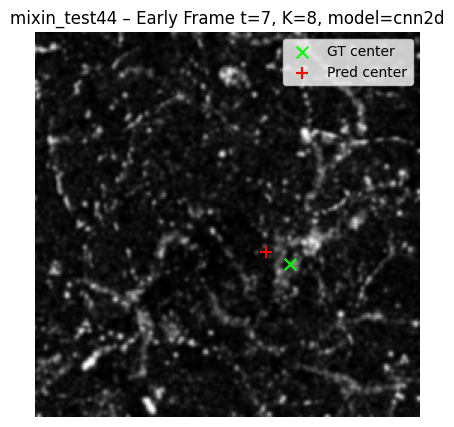

CNN2DRegressor(
  (features): Sequential(
    (0): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
  )
  (pool): AdaptiveAvgPool2d(output_size=1)
  (head): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=32, bias=True)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=2, bias=True)
    (4): Sigmoid()
  )
)

In [39]:
get_trained_model_for_visual("mixin_test44", K=8, model_type="cnn2d", epochs=15, batch_size=16)

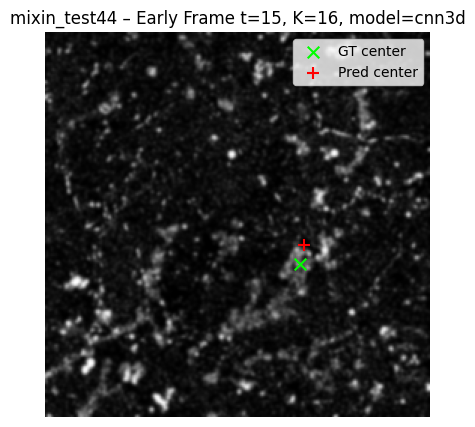

CNN3DRegressor(
  (features): Sequential(
    (0): Conv3d(1, 8, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): ReLU()
    (2): Conv3d(8, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (3): ReLU()
    (4): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (5): ReLU()
  )
  (pool): AdaptiveAvgPool3d(output_size=1)
  (head): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32, out_features=32, bias=True)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=2, bias=True)
    (4): Sigmoid()
  )
)

In [57]:
get_trained_model_for_visual("mixin_test44", K=16, model_type="cnn3d", epochs=15, batch_size=16)

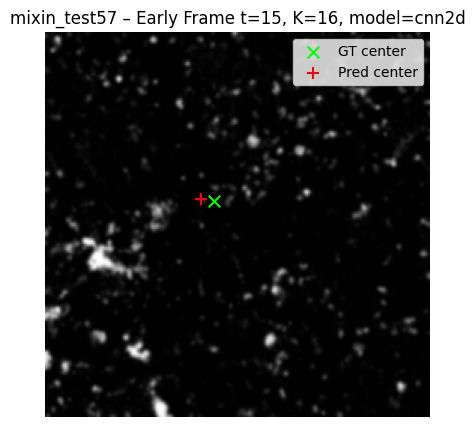

CNN2DRegressor(
  (features): Sequential(
    (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
  )
  (pool): AdaptiveAvgPool2d(output_size=1)
  (head): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=32, bias=True)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=2, bias=True)
    (4): Sigmoid()
  )
)

In [42]:
get_trained_model_for_visual("mixin_test57", K=16, model_type="cnn2d", epochs=15, batch_size=16)

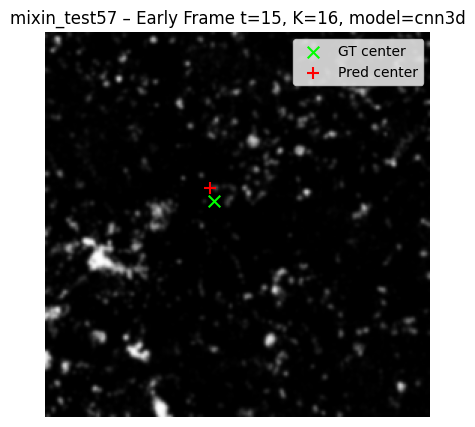

CNN3DRegressor(
  (features): Sequential(
    (0): Conv3d(1, 8, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): ReLU()
    (2): Conv3d(8, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (3): ReLU()
    (4): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (5): ReLU()
  )
  (pool): AdaptiveAvgPool3d(output_size=1)
  (head): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32, out_features=32, bias=True)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=2, bias=True)
    (4): Sigmoid()
  )
)

In [43]:
get_trained_model_for_visual("mixin_test57", K=16, model_type="cnn3d", epochs=15, batch_size=16)

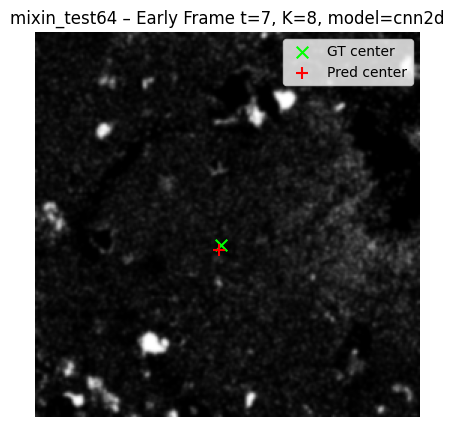

CNN2DRegressor(
  (features): Sequential(
    (0): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
  )
  (pool): AdaptiveAvgPool2d(output_size=1)
  (head): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=32, bias=True)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=2, bias=True)
    (4): Sigmoid()
  )
)

In [47]:
get_trained_model_for_visual("mixin_test64", K=8, model_type="cnn2d", epochs=15, batch_size=16)

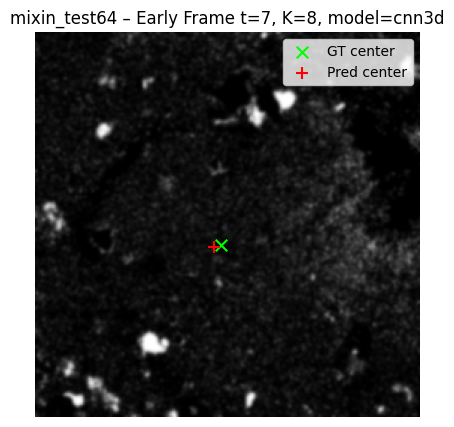

CNN3DRegressor(
  (features): Sequential(
    (0): Conv3d(1, 8, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): ReLU()
    (2): Conv3d(8, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (3): ReLU()
    (4): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (5): ReLU()
  )
  (pool): AdaptiveAvgPool3d(output_size=1)
  (head): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32, out_features=32, bias=True)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=2, bias=True)
    (4): Sigmoid()
  )
)

In [46]:
get_trained_model_for_visual("mixin_test64", K=8, model_type="cnn3d", epochs=15, batch_size=16)

## challenge

In [48]:
import cv2
import numpy as np
import torch

def compute_optical_flow(frames):
    """
    frames: numpy (T, H, W) normalized
    returns: flow field list, each is (H, W, 2)
    """
    flows = []
    for t in range(len(frames)-1):
        f1 = (frames[t] * 255).astype(np.uint8)
        f2 = (frames[t+1] * 255).astype(np.uint8)

        flow = cv2.calcOpticalFlowFarneback(
            f1, f2, None,
            pyr_scale=0.5, levels=3, winsize=15,
            iterations=3, poly_n=5, poly_sigma=1.2,
            flags=0
        )  # (H,W,2)
        flows.append(flow)
    return np.stack(flows)


In [49]:
def avg_velocity_field(flow_stack):
    """
    flow_stack: (T-1, H, W, 2)
    return: (H, W, 2)
    """
    return np.mean(flow_stack, axis=0)

def forward_integrate(vel, steps=20, step_size=1.0):
    """
    vel: (H,W,2)
    Returns density map of integrated particle endpoints.
    """
    H, W, _ = vel.shape
    yy, xx = np.meshgrid(np.arange(H), np.arange(W), indexing='ij')
    px = xx.astype(np.float32)
    py = yy.astype(np.float32)

    for _ in range(steps):
        vx = cv2.remap(vel[:,:,0], px, py, cv2.INTER_LINEAR)
        vy = cv2.remap(vel[:,:,1], px, py, cv2.INTER_LINEAR)
        px += vx * step_size
        py += vy * step_size
        px = np.clip(px, 0, W-1)
        py = np.clip(py, 0, H-1)

    # accumulate density
    heat = np.zeros((H,W), dtype=np.float32)
    ix = px.astype(np.int32)
    iy = py.astype(np.int32)
    for i in range(H):
        for j in range(W):
            heat[iy[i,j], ix[i,j]] += 1

    # normalize
    heat /= heat.max()
    return heat

def flow_based_prediction(pre):
    """
    pre: (T, H, W) normalized
    """
    flow_stack = compute_optical_flow(pre[:10])       # early 10 frames only
    vel = avg_velocity_field(flow_stack)
    heat = forward_integrate(vel, steps=30, step_size=1.2)
    r,c = np.unravel_index(np.argmax(heat), heat.shape)
    return (r, c), heat, vel


In [50]:
dataset_name = "mixin_test64"

raw = load_raw_movie(dataset_name, use_format="avi")
#raw = remove_black_frames(raw)
pre = preprocess_stack(raw)

print(pre.shape)   # (T, H, W)

(200, 256, 256)


Predicted aggregation center: (np.int64(164), np.int64(40))


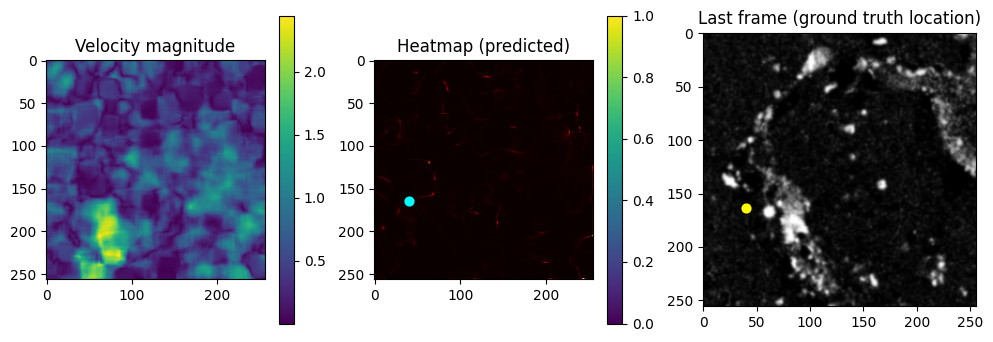

In [51]:
# Print predicted center
center_pred, heatmap, velocity = flow_based_prediction(pre[:16])
print("Predicted aggregation center:", center_pred)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Velocity magnitude")
plt.imshow(np.linalg.norm(velocity, axis=-1))
plt.colorbar()

plt.subplot(1,3,2)
plt.title("Heatmap (predicted)")
plt.imshow(heatmap, cmap='hot')
plt.scatter(center_pred[1], center_pred[0], s=40, c='cyan')
plt.colorbar()

plt.subplot(1,3,3)
plt.title("Last frame (ground truth location)")
plt.imshow(pre[-1], cmap='gray')
plt.scatter(center_pred[1], center_pred[0], c='yellow', s=40)

In [54]:
dataset_name = "mixin_test57"

raw = load_raw_movie(dataset_name, use_format="avi")
#raw = remove_black_frames(raw)
pre = preprocess_stack(raw)

print(pre.shape)   # (T, H, W)

(400, 256, 256)


Predicted aggregation center: (np.int64(32), np.int64(35))


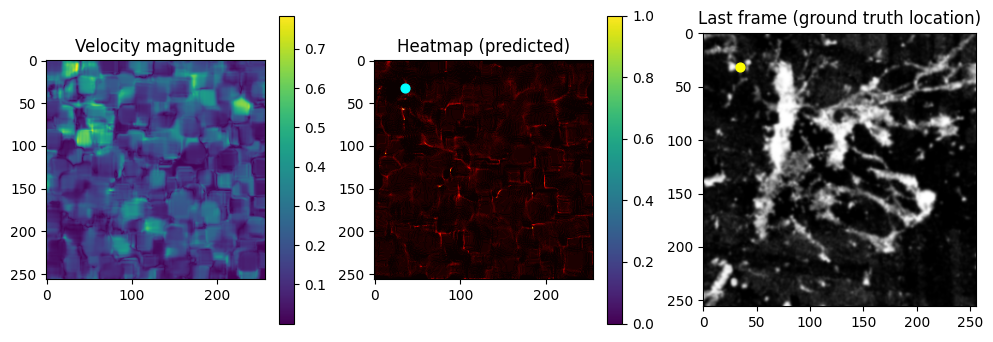

In [55]:
# Print predicted center
center_pred, heatmap, velocity = flow_based_prediction(pre[:16])
print("Predicted aggregation center:", center_pred)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Velocity magnitude")
plt.imshow(np.linalg.norm(velocity, axis=-1))
plt.colorbar()

plt.subplot(1,3,2)
plt.title("Heatmap (predicted)")
plt.imshow(heatmap, cmap='hot')
plt.scatter(center_pred[1], center_pred[0], s=40, c='cyan')
plt.colorbar()

plt.subplot(1,3,3)
plt.title("Last frame (ground truth location)")
plt.imshow(pre[-1], cmap='gray')
plt.scatter(center_pred[1], center_pred[0], c='yellow', s=40)